In [16]:
import numpy as np 


class Linearregression:
    def __init__(self,learningRate=0.01,n_iteration=1000):
        self.weights =None
        self.bias=None
        self.le=learningRate
        self.n_it=n_iteration
        self.loss_history=[]


    def fit(self, X,Y):
        print(X)

        n_samples,n_features=X.shape
        self.weights=np.zeros(n_features)
        self.bias=0

        for i in range(self.n_it):
            y_predicted= np.dot(X,self.weights)+self.bias

            loss =(1/(2*n_samples))*np.sum((y_predicted-Y)**2)
            print(loss)
            self.loss_history.append(loss)

            dw = (1/n_samples)*np.dot(X.T,(y_predicted-Y))
            db = (1/n_samples)*np.sum(y_predicted-Y)

            self.weights-=self.le*dw
            self.bias-=self.le*db

    def predict (self,X):
        return np.dot(X,self.weights)+self.bias

        

In [17]:
np.random.seed(42)

X=2*np.random.rand(100,1)
y=(3*X+5).squeeze()+np.random.randn(100)*0.1


model = Linearregression(learningRate=0.1,n_iteration=500)

model.fit(X,y)

print(f"Learned Weight (Target ≈ 3.0): {model.weights[0]:.4f}")
print(f"Learned Bias   (Target ≈ 5.0): {model.bias:.4f}")
print(f"Initial Loss: {model.loss_history[0]:.4f}")
print(f"Final Loss:   {model.loss_history[-1]:.4f}")

[[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]
 [0.31198904]
 [0.11616722]
 [1.73235229]
 [1.20223002]
 [1.41614516]
 [0.04116899]
 [1.9398197 ]
 [1.66488528]
 [0.42467822]
 [0.36364993]
 [0.36680902]
 [0.60848449]
 [1.04951286]
 [0.86389004]
 [0.58245828]
 [1.22370579]
 [0.27898772]
 [0.5842893 ]
 [0.73272369]
 [0.91213997]
 [1.57035192]
 [0.39934756]
 [1.02846888]
 [1.18482914]
 [0.09290083]
 [1.2150897 ]
 [0.34104825]
 [0.13010319]
 [1.89777107]
 [1.93126407]
 [1.6167947 ]
 [0.60922754]
 [0.19534423]
 [1.36846605]
 [0.88030499]
 [0.24407647]
 [0.99035382]
 [0.06877704]
 [1.8186408 ]
 [0.51755996]
 [1.32504457]
 [0.62342215]
 [1.04013604]
 [1.09342056]
 [0.36970891]
 [1.93916926]
 [1.55026565]
 [1.87899788]
 [1.7896547 ]
 [1.19579996]
 [1.84374847]
 [0.176985  ]
 [0.39196572]
 [0.09045458]
 [0.65066066]
 [0.77735458]
 [0.54269806]
 [1.65747502]
 [0.71350665]
 [0.56186902]
 [1.08539217]
 [0.28184845]
 [1.60439396]
 [0.14910129]
 [1.97377387]
 [1.54448954]
 [0.39

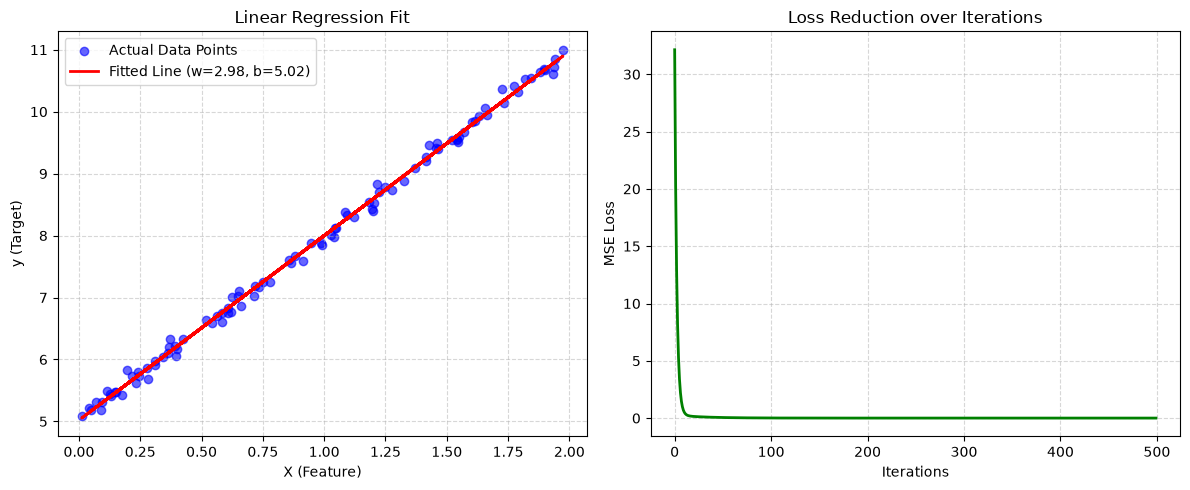

In [18]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Plot the Fitted Line vs. Actual Data
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Subplot 1: Regression Line
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data Points')
# Generate predictions across the X range
y_pred_line = model.predict(X)
plt.plot(X, y_pred_line, color='red', linewidth=2, label=f'Fitted Line (w={model.weights[0]:.2f}, b={model.bias:.2f})')

plt.title('Linear Regression Fit')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# 2. Plot the Loss Curve (Gradient Descent Convergence)
# ---------------------------------------------------------
plt.subplot(1, 2, 2)
plt.plot(range(len(model.loss_history)), model.loss_history, color='green', linewidth=2)
plt.title('Loss Reduction over Iterations')
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()